# Customer Retention Intelligence System

## Overview

This project analyzes customer churn patterns and predicts customers who are likely to leave a telecom company. 
The goal is to generate actionable retention insights and support data-driven business decisions.

## Dataset
- IBM Telco Customer Churn Dataset
- 7,043 customer records
- Target Variable: **Churn (Yes/No)**

## Project Workflow
1. Data Cleaning & Preprocessing
2. Exploratory Data Analysis (EDA)
3. Churn Prediction Modeling
4. SMOTE-Based Class Balancing
5. Feature Importance Analysis
6. Streamlit Application
7. Looker Studio Dashboard

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (7043, 21)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [6]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())

float64
11


In [7]:
df = df.dropna(subset=["TotalCharges"])
print(df.shape)
print(df["TotalCharges"].isnull().sum())

(7032, 21)
0


In [8]:
print(df["Churn"].value_counts())
churn_percentage = (
    df["Churn"].value_counts(normalize=True) * 100
)
print(churn_percentage)

Churn
No     5163
Yes    1869
Name: count, dtype: int64
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


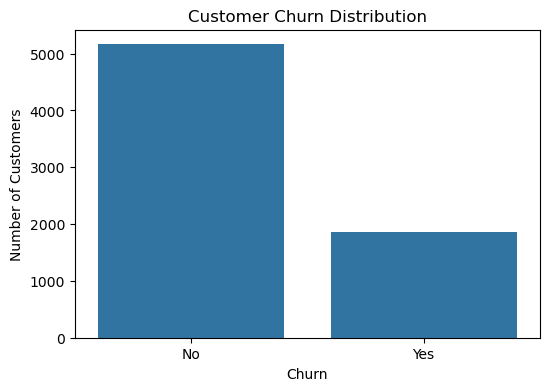

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

### Approximately 26.6% of customers have churned, while 73.4% have remained with the company.
#### This means roughly 1 out of every 4 customers leaves the service, making customer retention an important business challenge for the telecom company.

In [10]:
print(df["Contract"].value_counts())

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64


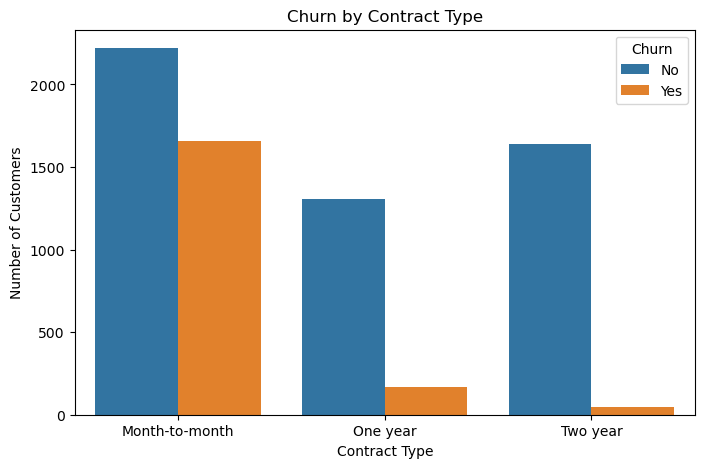

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df,x="Contract",hue="Churn")

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

#### Customers on month-to-month contracts exhibit substantially higher churn rates compared to customers on one-year and two-year contracts. 
#### Long-term contracts appear to improve customer retention and reduce customer attrition.

In [12]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn.round(2))

Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


#### The telecom company should target month-to-month customers with loyalty programs, contract upgrade offers, and retention campaigns to reduce churn.

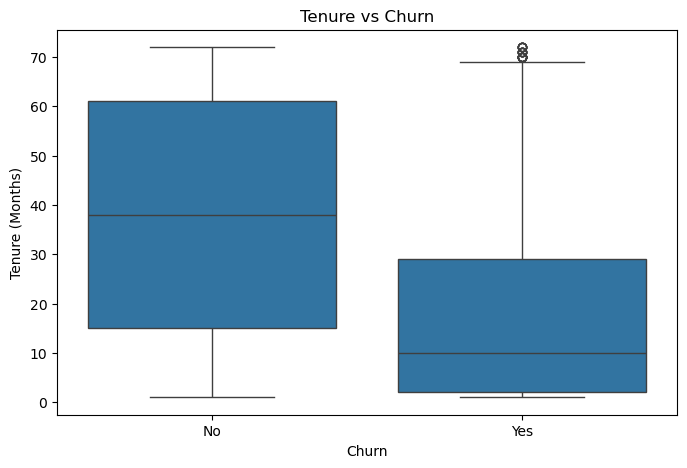

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

In [14]:
print(df.groupby("Churn")["tenure"].mean().round(2))

Churn
No     37.65
Yes    17.98
Name: tenure, dtype: float64


#### Customers who churned had an average tenure of only 17.98 months, while retained customers stayed for an average of 37.65 months. This indicates that newer customers are significantly more likely to leave, whereas long-term customers tend to remain loyal.

#### The company should focus on customer engagement and retention efforts during the early stages of the customer lifecycle, particularly within the first 1–2 years of service.

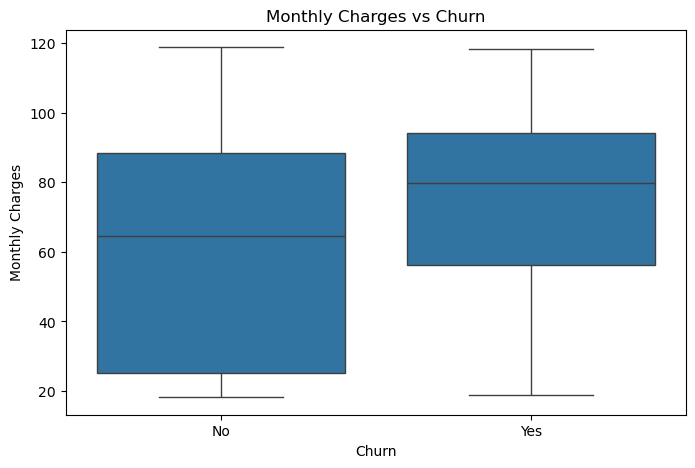

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()


In [16]:
df.groupby("Churn")["MonthlyCharges"].mean().round(2)

Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64

#### Customers who churned paid higher monthly charges on average ($74.44) compared to retained customers ($61.31). This suggests that customers with higher monthly costs may be more sensitive to pricing and could be at greater risk of leaving the company.

#### The company should closely monitor high-billing customers and consider loyalty discounts, bundled services, or personalized retention offers to reduce churn among valuable customers.

In [17]:
df_model = df.copy()
df_model = df_model.drop("customerID", axis=1)

df_model["Churn"] = df_model["Churn"].map({"No": 0,"Yes": 1})

df_model = pd.get_dummies(df_model,drop_first=True)

In [18]:
print(df_model.shape)
df_model.head()

(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df_model.drop("Churn", axis=1)
y = df_model["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (5625, 30)
Testing Shape: (1407, 30)


In [20]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test,y_pred_dt)
print("Decision Tree Accuracy:", round(dt_accuracy, 4))

print(classification_report(y_test,y_pred_dt))

Decision Tree Accuracy: 0.7214
              precision    recall  f1-score   support

           0       0.82      0.80      0.81      1033
           1       0.48      0.51      0.49       374

    accuracy                           0.72      1407
   macro avg       0.65      0.66      0.65      1407
weighted avg       0.73      0.72      0.72      1407



In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test,y_pred_rf)
print("Random Forest Accuracy:", round(rf_accuracy, 4))

print(classification_report(y_test,y_pred_rf))

Random Forest Accuracy: 0.7854
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.68      0.70      1407
weighted avg       0.77      0.79      0.77      1407



In [22]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42,eval_metric="logloss")

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test,y_pred_xgb)
print("XGBoost Accuracy:", round(xgb_accuracy, 4))

print(classification_report(y_test,y_pred_xgb))

XGBoost Accuracy: 0.774
              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.59      0.50      0.54       374

    accuracy                           0.77      1407
   macro avg       0.71      0.69      0.69      1407
weighted avg       0.76      0.77      0.77      1407



In [23]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print(y_train.value_counts())
print("\nAfter SMOTE:\n")
print(y_train_smote.value_counts())

Churn
0    4130
1    1495
Name: count, dtype: int64

After SMOTE:

Churn
1    4130
0    4130
Name: count, dtype: int64


In [24]:
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote,y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

rf_smote_accuracy = accuracy_score(y_test,y_pred_rf_smote)
print("Random Forest + SMOTE Accuracy:", round(rf_smote_accuracy, 4))

print(classification_report(y_test,y_pred_rf_smote))

Random Forest + SMOTE Accuracy: 0.774
              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.57      0.58      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

dt_smote = DecisionTreeClassifier(random_state=42)

dt_smote.fit(X_train_smote,y_train_smote)

y_pred_dt_smote = dt_smote.predict(X_test)

dt_smote_accuracy = accuracy_score(y_test,y_pred_dt_smote)

print("Decision Tree + SMOTE Accuracy:", round(dt_smote_accuracy, 4))

print(classification_report(y_test,y_pred_dt_smote))

Decision Tree + SMOTE Accuracy: 0.7249
              precision    recall  f1-score   support

           0       0.83      0.79      0.81      1033
           1       0.48      0.56      0.52       374

    accuracy                           0.72      1407
   macro avg       0.66      0.67      0.66      1407
weighted avg       0.74      0.72      0.73      1407



In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

xgb_smote = XGBClassifier(random_state=42,eval_metric="logloss")

xgb_smote.fit(X_train_smote,y_train_smote)

y_pred_xgb_smote = xgb_smote.predict(X_test)

xgb_smote_accuracy = accuracy_score(y_test,y_pred_xgb_smote)

print("XGBoost + SMOTE Accuracy:", round(xgb_smote_accuracy, 4))
print(classification_report(y_test,y_pred_xgb_smote))

XGBoost + SMOTE Accuracy: 0.7697
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.56      0.59      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407



#### Six models were evaluated, including Decision Tree, Random Forest, and XGBoost, both with and without SMOTE. While Random Forest achieved the highest overall accuracy (78.54%), XGBoost with SMOTE provided the best balance for churn prediction by achieving the highest churn recall (59%). Therefore, XGBoost with SMOTE was selected as the final model for customer retention analysis.

In [27]:
importance_df = pd.DataFrame({"Feature": X_train.columns,"Importance": xgb_smote.feature_importances_})

importance_df = importance_df.sort_values(by="Importance",ascending=False)
print(importance_df.head(10))

                                  Feature  Importance
28         PaymentMethod_Electronic check    0.269888
10            InternetService_Fiber optic    0.100665
11                     InternetService_No    0.086350
25                      Contract_Two year    0.055103
8          MultipleLines_No phone service    0.049475
26                   PaperlessBilling_Yes    0.043284
7                        PhoneService_Yes    0.038655
9                       MultipleLines_Yes    0.036107
27  PaymentMethod_Credit card (automatic)    0.035415
29             PaymentMethod_Mailed check    0.035251


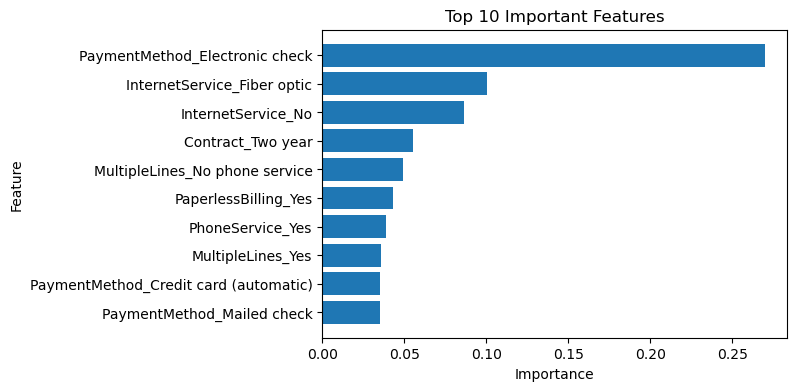

In [28]:
plt.figure(figsize=(6,4))

plt.barh(importance_df["Feature"].head(10),importance_df["Importance"].head(10))
plt.title("Top 10 Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.show()

EDA Findings:
- Month-to-month contracts churn more
- New customers churn more
- Higher monthly charges churn more

Model Findings:
- Electronic check is the strongest predictor
- Fiber optic service is important
- Two-year contracts reduce churn risk


In [29]:
import joblib

feature_columns = X_train.columns.tolist()
joblib.dump(xgb_smote,"xgb_churn_model.pkl")
joblib.dump(feature_columns,"feature_columns.pkl")


['feature_columns.pkl']